# Rota da Neuromante - MLP sem otimização

###### Notebook produzido por Ana Carolina Sayumi Imahata Alves

O principal objetivo deste notebook é desenvolver uma rede neural do tipo MLP Classificadora Binária para a atividade apresentada.

Observação: este notebook foi feito com base no tarablho anterior da disciplina entitulado "Trilha da Acadêmica". O link do GitHub está disponível em [1].

## Imports e tratamento dos dados

In [1]:
import lightning as L
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import random

import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
from matplotlib.pyplot import savefig

Antes de começar o código iremos estabelecer todas as seeds, para fins de reprodutibilidade.

In [2]:
SEED = 43

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
L.seed_everything(SEED, workers=True)

Seed set to 43


43

Feito isso, todo o tratamento de dados será feito dentro do DataModule do Lightning. Esse processo inclui a separação em treino, validação e teste.

In [3]:
class DataModule(L.LightningDataModule):
    def __init__(
        self,
        tamanho_teste=0.2,
        tamanho_val=0.1,
        tamanho_lote=32,
        num_trabalhadores=0,
        semente_aleatoria=43,
    ):
        super().__init__()

        self.tamanho_lote = tamanho_lote
        self.num_trabalhadores = num_trabalhadores
        self.tamanho_teste = tamanho_teste
        self.tamanho_val = tamanho_val
        self.semente_aleatoria = semente_aleatoria

    def prepare_data(self):
        pd.read_excel("Dataset_Alzheimers_sep.xlsx")

    def setup(self, stage):
        """Ocorre após o `prepare_data`. Aqui devemos alterar o estado da classe
        para adicionar as informações referentes aos conjuntos de treino, teste
        e validação. O argumento `stage` deve existir e ele indica em qual
        estágio o processo de treino está (pode ser `fit` para
        treinamento/validação e `test` para teste).

        É nesta etapa onde aplicamos transformações aos dados caso necessário.
        """

        df = pd.read_excel("Dataset_Alzheimers_sep.xlsx")

        df = df.reset_index(drop=True)

        # Passando o encoder
        le = LabelEncoder()
        df["Class"] = le.fit_transform(df["Class"])

        encoder = OneHotEncoder(sparse_output=False)
        genotype_encoded = encoder.fit_transform(df[["Genotype"]])
        genotype_cols = encoder.get_feature_names_out(["Genotype"])

        df = df.drop(columns=["Genotype"])
        df = pd.concat([df, pd.DataFrame(genotype_encoded, columns=genotype_cols, index=df.index)], axis=1)

        # Armazenando atributos e target
        ATRIBUTOS = df.columns.tolist()
        ATRIBUTOS.remove('Class')
        TARGET = ["Class"]

        # Atualizando o df e removendo dados ausentes
        df = df.reindex(ATRIBUTOS + TARGET, axis=1)

        df_target = df[TARGET]

        indices = df.index
        indices_treino_val, indices_teste = train_test_split(
            indices,
            test_size=self.tamanho_teste,
            random_state=self.semente_aleatoria,
            stratify=df_target
        )

        df_treino_val = df.loc[indices_treino_val]
        df_teste = df.loc[indices_teste]

        indices = df_treino_val.index
        indices_treino, indices_val = train_test_split(
            indices,
            test_size=self.tamanho_val,
            random_state=self.semente_aleatoria,
            stratify=df_treino_val[TARGET] 
        )

        df_treino = df.loc[indices_treino]
        df_val = df.loc[indices_val]

        X_treino = df_treino.reindex(ATRIBUTOS, axis=1).values
        y_treino = df_treino.reindex(TARGET, axis=1).values

        self.x_scaler = MaxAbsScaler()
        self.x_scaler.fit(X_treino)

        if stage == "fit":
            X_val = df_val.reindex(ATRIBUTOS, axis=1).values
            y_val = df_val.reindex(TARGET, axis=1).values

            X_treino = self.x_scaler.transform(X_treino)
            X_val = self.x_scaler.transform(X_val)

            self.X_treino = torch.tensor(X_treino, dtype=torch.float32)
            self.X_val = torch.tensor(X_val, dtype=torch.float32)
    
            self.y_treino = torch.tensor(y_treino, dtype=torch.long).squeeze(1)
            self.y_val   = torch.tensor(y_val,   dtype=torch.long).squeeze(1)

        if stage == "test":
            X_teste = df_teste.reindex(ATRIBUTOS, axis=1).values
            y_teste = df_teste.reindex(TARGET, axis=1).values

            X_teste = self.x_scaler.transform(X_teste)

            self.X_teste = torch.tensor(X_teste, dtype=torch.float32)
            self.y_teste = torch.tensor(y_teste, dtype=torch.long).squeeze(1)

    def train_dataloader(self):
        return DataLoader(
            TensorDataset(self.X_treino, self.y_treino),
            batch_size=self.tamanho_lote,
            num_workers=self.num_trabalhadores,
            shuffle=True,
        )

    def val_dataloader(self):
        return DataLoader(
            TensorDataset(self.X_val, self.y_val),
            batch_size=self.tamanho_lote * 2,
            num_workers=self.num_trabalhadores,
            shuffle=False,
        )

    def test_dataloader(self):
        return DataLoader(
            TensorDataset(self.X_teste, self.y_teste),
            batch_size=self.tamanho_lote * 2,
            num_workers=self.num_trabalhadores,
            shuffle=False,
        )

## Construindo a MLP

Para essa MLP de classificação, como temos um DataSet pequeno, iremos fazer uma arquitetura pouco complexa (visando evitar overffiting). Vale ressaltar que adicionamos pesos à função de perda, uma vez que temos dados levemente desbalanceados (os pesos foram definidos a partir da proporção de uma categoria para a outra).


In [4]:
class MLP_simples(L.LightningModule):
    def __init__(
        self, num_dados_entrada, neuronios_c1, neuronios_c2, neuronios_c3, num_targets):
        super().__init__()

        self.camadas = nn.Sequential(
            nn.Linear(num_dados_entrada, neuronios_c1),
            nn.ReLU(),
            nn.Linear(neuronios_c1, neuronios_c2),
            nn.ReLU(),
            nn.Linear(neuronios_c2, neuronios_c3),
            nn.ReLU(),
            nn.Linear(neuronios_c3, num_targets),
        )

        self.fun_perda = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 2.7]))

        self.perdas_treino = []
        self.perdas_val = []

        self.curva_aprendizado_treino = []
        self.curva_aprendizado_val = []

    def forward(self, x):
        x = self.camadas(x)
        return x

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.fun_perda(y_pred, y)

        self.log("loss", loss, prog_bar=True)
        self.perdas_treino.append(loss)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.fun_perda(y_pred, y)

        self.log("val_loss", loss, prog_bar=True)
        self.perdas_val.append(loss)

        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.fun_perda(y_pred, y)

        self.log("test_loss", loss)

        return loss

    def on_train_epoch_end(self):
        # Atualiza curva de aprendizado
        perda_media = torch.stack(self.perdas_treino).mean()
        self.curva_aprendizado_treino.append(float(perda_media))
        self.perdas_treino.clear()

    def on_validation_epoch_end(self):
        # Atualiza curva de aprendizado
        perda_media = torch.stack(self.perdas_val).mean()
        self.curva_aprendizado_val.append(float(perda_media))
        self.perdas_val.clear()

Uma vez que definimos a arquitetura no Lightining podemos definir as épocas e treinar o modelo. 

Observação: através de observações da curva de aprendizado, foram fixadas 120 épocas para nosso modelo.

In [5]:
NUM_EPOCAS = 120

treinador = L.Trainer(max_epochs=NUM_EPOCAS, deterministic=True)

dm = DataModule()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


*Abaixo obtemos o número de atributos para passar como argumento em nosso modelo. 

In [6]:
dm_atributos_check = DataModule()
dm_atributos_check.setup("fit")
print(dm_atributos_check.X_treino.shape[1])  # número real de atributos

136


In [7]:
num_dados_de_entrada = 136
num_targets = 2
neuronios_c1 = 4
neuronios_c2 = 3
neuronios_c3 = 2

MLP_s_otim = MLP_simples(
    num_dados_de_entrada, neuronios_c1, neuronios_c2, neuronios_c3, num_targets)

treinador.fit(MLP_s_otim, dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | camadas   | Sequential       | 577    | train | 0    
1 | fun_perda | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
577       Trainable params
0         Non-trainable params
577       Total params
0.002     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of tra

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=120` reached.


Agora geramos a curva de aprendizado para avaliar a convergência.

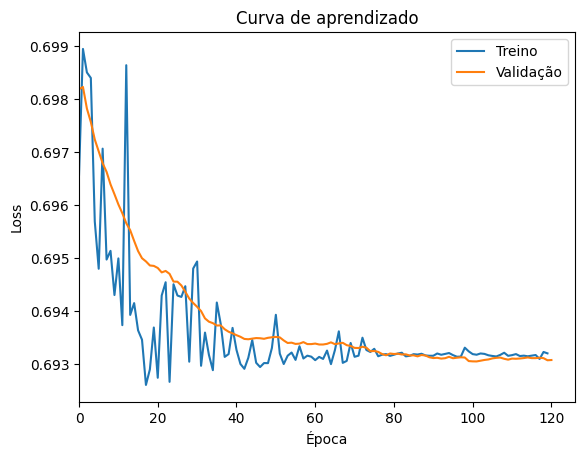

In [8]:
ca_treino = MLP_s_otim.curva_aprendizado_treino
ca_val = MLP_s_otim.curva_aprendizado_val

sns.lineplot(ca_treino, label="Treino")
eixo = sns.lineplot(ca_val, label="Validação")

eixo.set_xlim(left=0)
eixo.set(title="Curva de aprendizado", xlabel="Época", ylabel="Loss");

Feito isso alteramos o estado da classe para finalmente testar a rede.

In [9]:
MLP_s_otim.eval()
dm.setup("test")

E geramos os resultados e a matriz de confusão para avaliar seu desempenho.

C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

              precision    recall  f1-score   support

     Control       0.73      1.00      0.84        49
    Impaired       0.00      0.00      0.00        18

    accuracy                           0.73        67
   macro avg       0.37      0.50      0.42        67
weighted avg       0.53      0.73      0.62        67



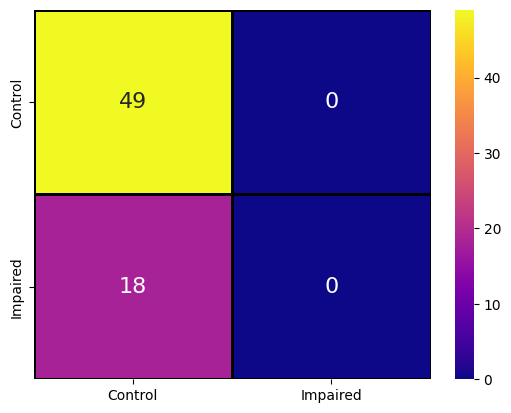

In [10]:
with torch.no_grad():
    y_pred_classes = MLP_s_otim(dm.X_teste).argmax(dim=1).numpy()
    y_true = dm.y_teste.numpy()

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=["Control", "Impaired"]))

# Confusion matrix
labels = ["Control", "Impaired"]
matriz_conf = confusion_matrix(y_true, y_pred_classes)
df_conf = pd.DataFrame(matriz_conf, labels, labels)

sns.heatmap(df_conf, cmap="plasma", annot=True, annot_kws={"size": 16}, linewidths=1, linecolor='black')

savefig("ConfMat_MLP_s_otim.png")

## Resultados e conclusão

Podemos ver que, mesmo com pesos, nossa rede falhou em prever a classe "Impaired", o que a torna pouco razoável para esse problema. Seu F1-score médio foi de 0.42.

Para análise comparativa dos resultados, retorne ao notebook `0 - A Rota da Neuromante - Análise do problema, discussão de resultados e conclusão`.

## Referências

[1] Disponível: https://github.com/anacsialves/MPL_para_classificacao-Disciplina_de_Redes_Neurais